# Proyek Analisis Data: Bike Sharing Dataset
- **Nama:** Evan Arlen Handy
- **Email:** cloaaa00@gmail.com
- **ID Dicoding:** warlord194

## Menentukan Pertanyaan Bisnis

- Bagaimana pola penyewaan sepeda berdasarkan waktu (jam, hari, dan musim) dan faktor cuaca?
- Apa karakteristik pengguna sepeda dan bagaimana membedakan pelanggan terdaftar (registered) dan kasual (casual)?

In [1]:
!pip install pipreqsnb

  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 798.3/798.3 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 29.4 MB/s eta 0:00:00
  Created wheel for pipreqsnb: filename=pipreqsnb-0.2.4-py3-none-any.whl size=4129 sha256=888fa43e75f95f13a7fba6c97a628a5d11bf263ff6c368ea9a34c513f2881cfa
  Stored in directory: /root/.cache/pip/wheels/48/2a/a3/6caa16bfb260624b06acb2a0eeb0bc45c2cd2f0ee2b5ac2d84
  Created wheel for docopt: filename=docopt-0.6.2-py2.py3-none-any.whl size=13706 sha256=246caafe22b19fe1cacf383e3da0cdc8551b22e910d6d74180be4de1f29dd3ef
  Stored in directory: /root/.cache/pip/wheels/1a/b0/8c/4b75c4116c31f83c8f9f047231251e13cc74481cca4a78a9ce
Successfully built pipreqsnb docopt
  Attempting uninstall: ipython
    Found existing installation: ipython 7.34.0
    Uninstalling ipython-7.34.0:
      Successfully uninstalled ipython-7.34.0
ERROR: pip's dependency resolver does not c

## Import Semua Packages/Library yang Digunakan

Berikut adalah library yang digunakan dalam analisis data dan visualisasi:

- **NumPy (`numpy`)** → Digunakan untuk komputasi numerik dan manipulasi array.
- **Pandas (`pandas`)** → Untuk manipulasi dan analisis data berbasis tabel (DataFrame).
- **Matplotlib (`matplotlib.pyplot`)** → Untuk membuat visualisasi data dalam bentuk grafik atau plot.
- **Seaborn (`seaborn`)** → Untuk visualisasi data yang lebih estetis dan statistik.
- **Matplotlib Ticker (`matplotlib.ticker.FuncFormatter`)** → Digunakan untuk format label pada sumbu grafik.
- **Plotly Express (`plotly.express`)** → Untuk visualisasi interaktif menggunakan Plotly.
- **Plotly Graph Objects (`plotly.graph_objects`)** → Untuk pembuatan grafik lanjutan dengan Plotly.
- **`plt.style.use('ggplot')`** → Menggunakan gaya 'ggplot' untuk grafik Matplotlib.  
- **`sns.set(style="whitegrid")`** → Mengatur gaya Seaborn menjadi 'whitegrid'.  


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter
import plotly.express as px
import plotly.graph_objects as go
plt.style.use('ggplot')
sns.set(style="whitegrid")

## Data Wrangling

### Gathering Data

Notebook ini menyajikan analisis dari **Dataset Bike Sharing**. Tujuannya adalah untuk memahami pola penyewaan sepeda berdasarkan waktu, cuaca, dan karakteristik pengguna. Dataset ini berisi informasi tentang penyewaan sepeda, termasuk:
- **Data temporal**: Jam, hari, bulan, dan tahun.
- **Data cuaca**: Suhu, kelembaban, kecepatan angin, dan kondisi cuaca.
- **Data pengguna**: Jumlah pengguna kasual dan terdaftar.


In [2]:
# Load datasets
day_df = pd.read_csv("data/day.csv")
hour_df = pd.read_csv("data/hour.csv")

**Insight:**
- Dataset terdiri dari dua file: `day.csv` dan `hour.csv`.
- `day.csv` berisi data harian, sedangkan `hour.csv` berisi data per jam.

### Assessing Data

##### Menilai Kualitas dan Struktur Data

Sebelum membersihkan data, kita perlu menilai kualitas dan struktur data yang meliputi:

1. **Memeriksa nilai yang hilang (missing values).**  
   - Menggunakan `.isna().sum()` untuk memeriksa nilai yang hilang.  

2. **Mengidentifikasi duplikat.**  
   - Menggunakan `.duplicated().sum()` untuk menghitung jumlah duplikat.  

3. **Meninjau tipe data dan ringkasan statistik.**  
   - Menggunakan `.info()` untuk melihat tipe data dari setiap kolom.  
   - Menggunakan `.describe()` untuk melihat ringkasan statistik numerik.  


In [3]:
print("Day Dataset Info:")
day_df.info()

Day Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB


In [4]:
print("\nHourly Dataset Info:")
hour_df.info()


Hourly Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB


In [5]:
print("\nMissing values in Day Dataset:")
print(day_df.isna().sum())


Missing values in Day Dataset:
instant       0
dteday        0
season        0
yr            0
mnth          0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64


In [6]:
print("\nMissing values in Hourly Dataset:")
print(hour_df.isna().sum())


Missing values in Hourly Dataset:
instant       0
dteday        0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64


In [7]:
# Check for duplicates
print(f"\nDuplicates in Day Dataset: {day_df.duplicated().sum()}")
print(f"Duplicates in Hourly Dataset: {hour_df.duplicated().sum()}")


Duplicates in Day Dataset: 0
Duplicates in Hourly Dataset: 0


In [8]:
print("\nDay Dataset Statistical Summary:")
display(day_df.describe())


Day Dataset Statistical Summary:


,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


In [9]:
print("\nHourly Dataset Statistical Summary:")
display(hour_df.describe())


Hourly Dataset Statistical Summary:


,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
std,5017.0295,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599
min,1.0000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


**Insight:**
- Tidak ada nilai yang hilang (missing values) dalam dataset.
- Tidak ada duplikat dalam dataset.
- Dataset memiliki kolom seperti `dteday` (tanggal), `season` (musim), `weathersit` (kondisi cuaca), dan `cnt` (total penyewaan).

### Cleaning Data

Proses pembersihan data meliputi beberapa langkah berikut:  

1. **Menghapus kolom yang tidak relevan.**  
   - Menggunakan `.drop(columns=['nama_kolom'])` untuk menghapus kolom yang tidak diperlukan.  

2. **Mengubah kolom tanggal ke format datetime.**  
   - Menggunakan `pd.to_datetime(df['tanggal_kolom'])` untuk mengonversi kolom tanggal agar lebih mudah dianalisis.  

3. **Mengubah nama kolom agar lebih mudah dipahami.**  
   - Menggunakan `.rename(columns={'kolom_lama': '`


In [10]:
def clean_bike_data(df, is_hourly=False):
    """
    Clean and transform bike sharing dataset

    Parameters:
    df (DataFrame): DataFrame to clean
    is_hourly (bool): Whether the dataset contains hourly data

    Returns:
    DataFrame: Cleaned DataFrame
    """
    cleaned_df = df.copy()

    if 'instant' in cleaned_df.columns:
        cleaned_df.drop('instant', axis=1, inplace=True)

    if 'workingday' in cleaned_df.columns:
        cleaned_df.drop('workingday', axis=1, inplace=True)

    cleaned_df['dteday'] = pd.to_datetime(cleaned_df['dteday'])

    cat_columns = ['season', 'mnth', 'holiday', 'weekday', 'weathersit']
    for col in cat_columns:
        if col in cleaned_df.columns:
            cleaned_df[col] = cleaned_df[col].astype('category')

    column_mapping = {
        'yr': 'year',
        'mnth': 'month',
        'weekday': 'day_of_week',
        'weathersit': 'weather',
        'windspeed': 'wind_speed',
        'cnt': 'total_rentals',
        'hum': 'humidity',
    }

    if is_hourly:
        column_mapping['hr'] = 'hour'

    cleaned_df.rename(columns=column_mapping, inplace=True)

    # Season mapping
    season_mapping = {1: 'Spring', 2: 'Summer', 3: 'Fall', 4: 'Winter'}
    cleaned_df['season'] = cleaned_df['season'].map(season_mapping)

    # Month mapping
    month_mapping = {
        1: 'Jan', 2: 'Feb', 3: 'Mar', 4: 'Apr', 5: 'May', 6: 'Jun',
        7: 'Jul', 8: 'Aug', 9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Dec'
    }
    cleaned_df['month'] = cleaned_df['month'].map(month_mapping)

    # Weather mapping
    weather_mapping = {
        1: 'Clear', 2: 'Cloudy/Misty', 3: 'Light Rain/Snow', 4: 'Heavy Rain/Snow'
    }
    cleaned_df['weather'] = cleaned_df['weather'].map(weather_mapping)

    # Day of week mapping
    day_mapping = {
        0: 'Sunday', 1: 'Monday', 2: 'Tuesday', 3: 'Wednesday',
        4: 'Thursday', 5: 'Friday', 6: 'Saturday'
    }
    cleaned_df['day_of_week'] = cleaned_df['day_of_week'].map(day_mapping)

    # Year mapping
    cleaned_df['year'] = cleaned_df['year'].map({0: '2011', 1: '2012'})

    # Scale humidity from 0-1 to percentage
    cleaned_df['humidity'] = cleaned_df['humidity'] * 100

    # Create day category (weekday/weekend)
    cleaned_df['day_type'] = cleaned_df['day_of_week'].apply(
        lambda x: 'Weekend' if x in ['Saturday', 'Sunday'] else 'Weekday'
    )

    # Create humidity category
    def classify_humidity(humidity):
        if humidity < 45:
            return "Dry"
        elif humidity < 65:
            return "Optimal"
        else:
            return "Humid"

    cleaned_df['humidity_category'] = cleaned_df['humidity'].apply(classify_humidity)

    # Create temperature category
    def classify_temp(temp):
        celsius = temp * 41
        if celsius < 10:
            return "Cold"
        elif celsius < 25:
            return "Moderate"
        else:
            return "Hot"

    cleaned_df['temp_category'] = cleaned_df['temp'].apply(classify_temp)

    # Create an actual temperature column in Celsius
    cleaned_df['temp_celsius'] = cleaned_df['temp'] * 41

    # Extract month and year from date for time series analysis
    cleaned_df['month_year'] = cleaned_df['dteday'].dt.to_period('M')

    return cleaned_df

In [11]:
# Clean both datasets
day_clean = clean_bike_data(day_df)
hour_clean = clean_bike_data(hour_df, is_hourly=True)

In [12]:
# Check the cleaned datasets
print("Cleaned daily dataset:")
display(day_clean.head())

print("\nCleaned hourly dataset:")
display(hour_clean.head())

Cleaned daily dataset:


,dteday,season,year,month,holiday,day_of_week,weather,temp,atemp,humidity,wind_speed,casual,registered,total_rentals,day_type,humidity_category,temp_category,temp_celsius,month_year
0,2011-01-01,Spring,2011,Jan,0,Saturday,Cloudy/Misty,0.344167,0.363625,80.5833,0.160446,331,654,985,Weekend,Humid,Moderate,14.110847,2011-01
1,2011-01-02,Spring,2011,Jan,0,Sunday,Cloudy/Misty,0.363478,0.353739,69.6087,0.248539,131,670,801,Weekend,Humid,Moderate,14.902598,2011-01
2,2011-01-03,Spring,2011,Jan,0,Monday,Clear,0.196364,0.189405,43.7273,0.248309,120,1229,1349,Weekday,Dry,Cold,8.050924,2011-01
3,2011-01-04,Spring,2011,Jan,0,Tuesday,Clear,0.200000,0.212122,59.0435,0.160296,108,1454,1562,Weekday,Optimal,Cold,8.200000,2011-01
4,2011-01-05,Spring,2011,Jan,0,Wednesday,Clear,0.226957,0.229270,43.6957,0.186900,82,1518,1600,Weekday,Dry,Cold,9.305237,2011-01



Cleaned hourly dataset:


,dteday,season,year,month,hour,holiday,day_of_week,weather,temp,atemp,humidity,wind_speed,casual,registered,total_rentals,day_type,humidity_category,temp_category,temp_celsius,month_year
0,2011-01-01,Spring,2011,Jan,0,0,Saturday,Clear,0.24,0.2879,81.0,0.0,3,13,16,Weekend,Humid,Cold,9.84,2011-01
1,2011-01-01,Spring,2011,Jan,1,0,Saturday,Clear,0.22,0.2727,80.0,0.0,8,32,40,Weekend,Humid,Cold,9.02,2011-01
2,2011-01-01,Spring,2011,Jan,2,0,Saturday,Clear,0.22,0.2727,80.0,0.0,5,27,32,Weekend,Humid,Cold,9.02,2011-01
3,2011-01-01,Spring,2011,Jan,3,0,Saturday,Clear,0.24,0.2879,75.0,0.0,3,10,13,Weekend,Humid,Cold,9.84,2011-01
4,2011-01-01,Spring,2011,Jan,4,0,Saturday,Clear,0.24,0.2879,75.0,0.0,0,1,1,Weekend,Humid,Cold,9.84,2011-01


**Insight:**
- Data telah dibersihkan dan diubah menjadi format yang lebih mudah dipahami.
- Kolom seperti `season`, `weather`, dan `day_of_week` telah dikonversi ke dalam kategori yang lebih deskriptif.


## Exploratory Data Analysis (EDA)

### Explore Temporal Patterns

Eksplorasi data bertujuan untuk mengidentifikasi pola dan hubungan dalam dataset.


### Mengelompokkan data penyewaan sepeda berdasarkan jam (`hour`) dan jenis hari (`day_type`: Weekday/Weekend)

In [13]:
hourly_agg = hour_clean.groupby(['hour', 'day_type']).agg({
    'total_rentals': ['mean', 'sum', 'count'],
    'casual': 'sum',
    'registered': 'sum'
}).reset_index()

hourly_agg

hour day_type total_rentals               casual registered
                          mean     sum count    sum        sum
0     0  Weekday     37.626692   19453   517   3850      15603
1     0  Weekend     94.148325   19677   209   3525      16152
2     1  Weekday     17.464078    8994   515   2024       6970
3     1  Weekend     72.583732   15170   209   2685      12485
4     2  Weekday      9.377953    4764   508   1206       3558
5     2  Weekend     55.980676   11588   207   2206       9382
6     3  Weekday      5.188525    2532   488    487       2045
7     3  Weekend     26.995215    5642   209   1406       4236
8     4  Weekday      5.446939    2669   490    396       2273
9     4  Weekend      8.497585    1759   207    478       1281
10    5  Weekday     24.331395   12555   516    662      11893
11    5  Weekend      8.487562    1706   201    350       1356
12    6  Weekday     99.485493   51434   517   2216      49218
13    6  Weekend     17.778846    3698   208    801       2897
14    7  Weekday    282.145068  145869   517   6227     139642
15    7  Weekend     39.533333    8302   210   1810       6492
16    8  Weekday    464.557060  240176   517  11539     228637
17    8  Weekend     99.166667   20825   210   4222      16603
18    9  Weekday    238.661509  123388   517  12982     110406
19    9  Weekend    171.666667   36050   210   9476      26574
20   10  Weekday    138.133462   71415   517  16982      54433
21   10  Weekend    261.152381   54842   210  16807      38035
22   11  Weekday    161.897485   83701   517  20536      63165
23   11  Weekend    321.995238   67619   210  22750      44869
24   12  Weekday    204.320463  105838   518  22641      83197
25   12  Weekend    374.171429   78576   210  27077      51499
26   13  Weekday    202.479769  105087   519  23405      81682
27   13  Weekend    380.152381   79832   210  29308      50524
28   14  Weekday    187.728324   97431   519  25031      72400
29   14  Weekend    372.480952   78221   210  30058      48163
30   15  Weekday    203.913295  105831   519  24932      80899
31   15  Weekend    368.180952   77318   210  29674      47644
32   16  Weekday    292.280769  151986   520  25952     126034
33   16  Weekend    360.771429   75762   210  27882      47880
34   17  Weekday    515.915385  268276   520  29972     238304
35   17  Weekend    326.590476   68584   210  24248      44336
36   18  Weekday    483.184971  250773   519  26387     224386
37   18  Weekend    282.291866   58999   209  18109      40890
38   19  Weekday    343.277457  178161   519  21457     156704
39   19  Weekend    232.669856   48628   209  14048      34580
40   20  Weekday    246.815029  128097   519  16589     111508
41   20  Weekend    174.416268   36453   209   9789      26664
42   21  Weekday    184.620424   95818   519  13015      82803
43   21  Weekend    141.755981   29627   209   7555      22072
44   22  Weekday    137.194605   71204   519  10286      60918
45   22  Weekend    116.784689   24408   209   5914      18494
46   23  Weekday     87.462428   45393   519   6870      38523
47   23  Weekend     88.746411   18548   209   4195      14353

**Insight:**
- Penyewaan di jam sibuk lebih tinggi pada hari kerja, dengan pengguna terdaftar mendominasi.
- Pada akhir pekan, penyewaan lebih merata, dengan pengguna terdaftar mendominasi.

### Mengelompokkan data penyewaan sepeda berdasarkan kondisi cuaca (`weather`)

In [14]:
weather_agg = day_clean.groupby('weather').agg({
    'total_rentals': ['mean', 'sum'],
    'casual': 'mean',
    'registered': 'mean',
    'temp_celsius': 'mean',
    'humidity': 'mean'
}).reset_index()

weather_agg

<ipython-input-14-3cfc3b62e5dd>:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  weather_agg = day_clean.groupby('weather').agg({


weather total_rentals               casual   registered  \
                            mean      sum        mean         mean   
0            Clear   4876.786177  2257952  964.030238  3912.755940   
1     Cloudy/Misty   4035.862348   996858  687.352227  3348.510121   
2  Light Rain/Snow   1803.285714    37869  185.476190  1617.809524   

  temp_celsius   humidity  
          mean       mean  
0    20.973200  56.559439  
1    19.284996  72.588678  
2    17.771046  84.887248

**Insight:**

- Kondisi Clear (Cerah) memiliki jumlah penyewaan terbanyak dibanding kondisi cuaca lainnya.
- Penyewaan menurun secara signifikan pada cuaca hujan & bersalju.
- Pengguna kasual (casual) cenderung berkurang lebih drastis saat cuaca buruk.
- Pengguna terdaftar (registered) lebih stabil karena mereka mungkin menggunakan sepeda untuk keperluan kerja.


### Mengelompokkan data penyewaan sepeda berdasarkan musim (`season`) dan jenis hari (`day_type`)

In [15]:
user_comparison = day_clean.groupby(['season', 'day_type']).agg({
    'casual': ['sum', 'mean'],
    'registered': ['sum', 'mean'],
    'total_rentals': 'sum'
}).reset_index()

user_comparison

<ipython-input-15-b715e8236595>:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  user_comparison = day_clean.groupby(['season', 'day_type']).agg({


season day_type  casual              registered              total_rentals
                       sum         mean        sum         mean           sum
0  Spring  Weekday   30367   239.110236     315113  2481.204724        345480
1  Spring  Weekend   30255   560.277778      95613  1770.611111        125868
2  Summer  Weekday  103775   786.174242     546475  4139.962121        650250
3  Summer  Weekend   99747  1918.211538     168592  3242.153846        268339
4    Fall  Weekday  127574   944.992593     644330  4772.814815        771904
5    Fall  Weekend   98517  1858.811321     190708  3598.264151        289225
6  Winter  Weekday   63928   503.370079     539283  4246.322835        603211
7  Winter  Weekend   65854  1291.254902     172548  3383.294118        238402

**Insight:**
- Total penyewaan tertinggi terjadi di musim gugur, kemungkinan karena cuaca masih nyaman untuk bersepeda tanpa panas ekstrem.
- Di musim panas (Summer), pengguna kasual meningkat signifikan karena cuaca lebih mendukung untuk bersepeda rekreasi.


### Memvisualisasikan distribusi empat variabel numerik dalam dataset `day_clean`, yaitu:
1. **Suhu dalam Celsius (`temp_celsius`)**  
2. **Kelembaban (`humidity`)**  
3. **Kecepatan angin (`wind_speed`)**  
4. **Total penyewaan sepeda (`total_rentals`)**

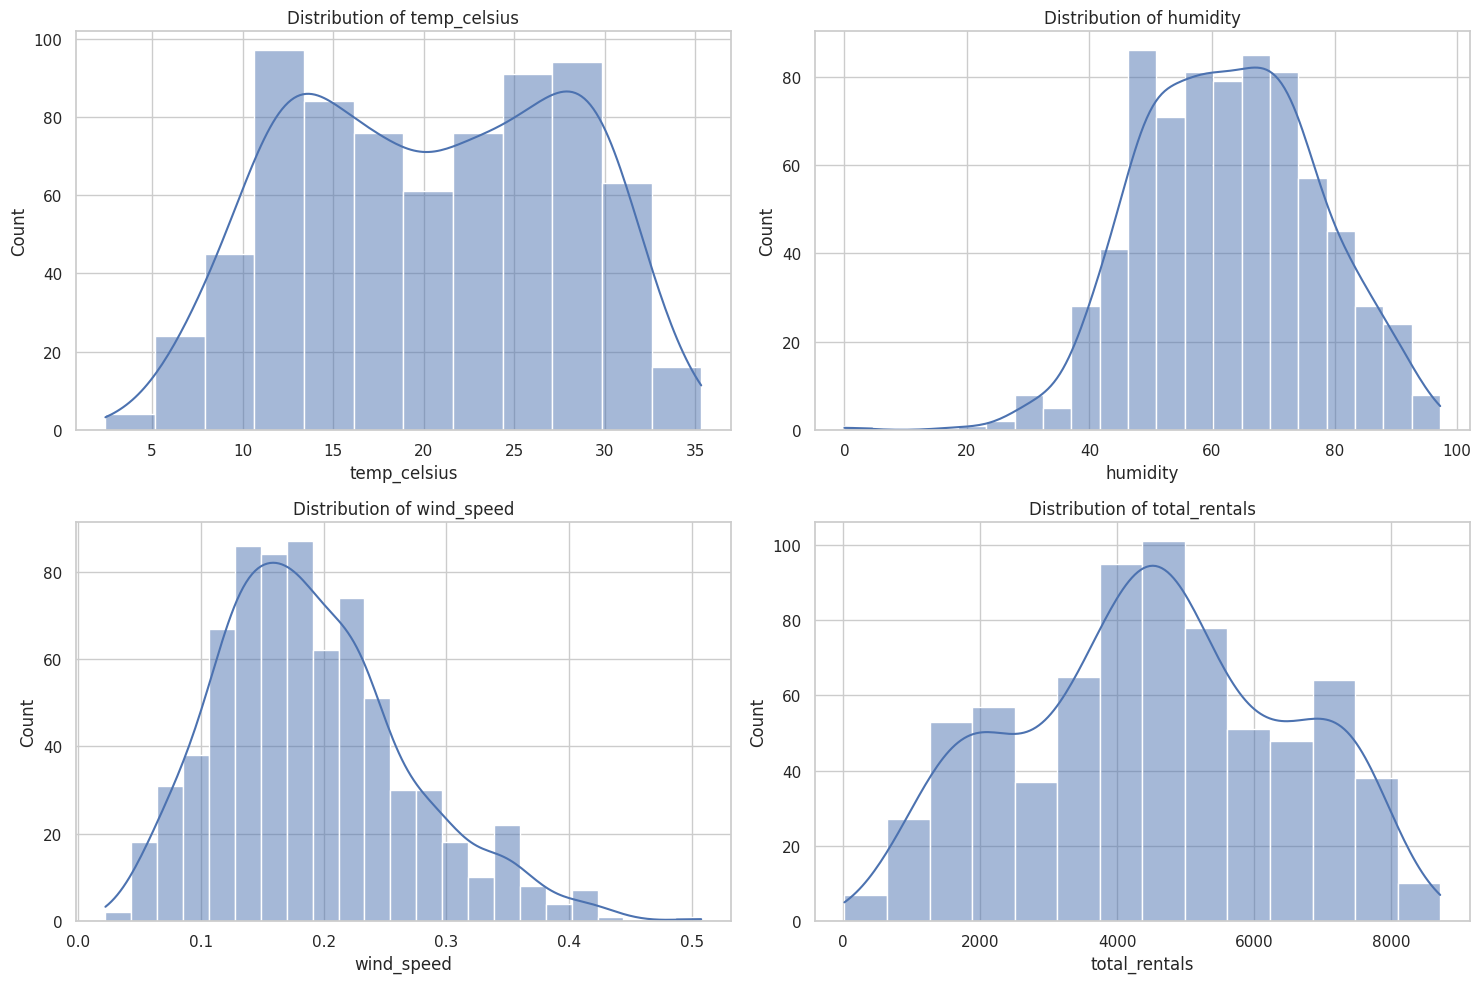

In [16]:
plt.figure(figsize=(15, 10))
for i, col in enumerate(['temp_celsius', 'humidity', 'wind_speed', 'total_rentals']):
    plt.subplot(2, 2, i+1)
    sns.histplot(day_clean[col], kde=True)
    plt.title(f'Distribution of {col}')
plt.tight_layout()

**Insight:**
- Suhu (temp_celsius) memiliki pengaruh signifikan terhadap penyewaan sepeda, terutama karena adanya pola musim.
- Hari dengan kelembaban tinggi (di atas 80%) mungkin kurang diminati oleh pengguna sepeda, karena kondisi yang kurang nyaman.
- Kecepatan angin sebagian besar rendah, sehingga angin bukan faktor utama yang menghambat penyewaan sepeda.
- Distribusi total penyewaan sepeda menunjukkan bahwa sebagian besar hari memiliki penyewaan yang cukup tinggi, yang berarti penggunaan sepeda cukup populer.


### Menampilkan distribusi variabel kategorikal dalam dataset `day_clean`, yaitu:  
1. **Musim (`season`)**  
2. **Bulan (`month`)**  
3. **Cuaca (`weather`)**  
4. **Hari dalam Seminggu (`day_of_week`)**

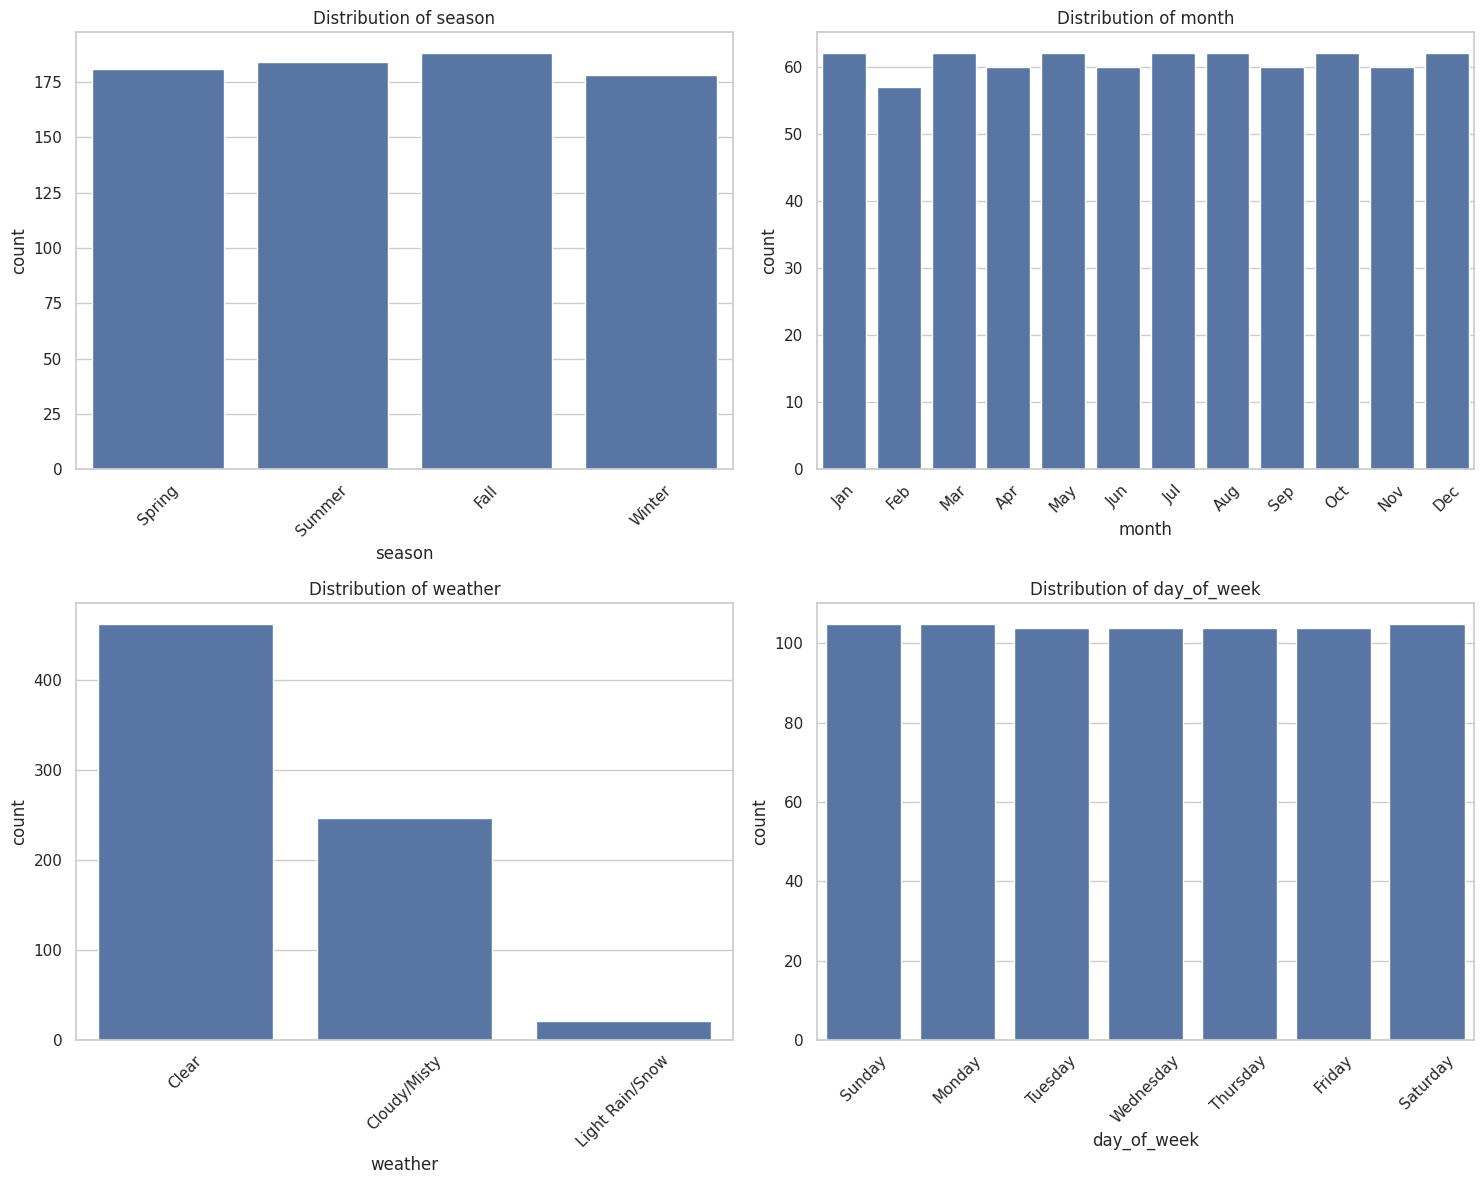

In [17]:
categorical_cols = ['season', 'month', 'weather', 'day_of_week']
plt.figure(figsize=(15, 12))
for i, col in enumerate(categorical_cols):
    plt.subplot(2, 2, i+1)
    sns.countplot(data=day_clean, x=col)
    plt.title(f'Distribution of {col}')
    plt.xticks(rotation=45)
plt.tight_layout()

**Insight:**
- Data terdistribusi hampir merata di setiap musim (Spring, Summer, Fall, Winter).
- Setiap bulan memiliki jumlah observasi yang relatif sama.
- Mayoritas data berada pada kategori Clear (Cerah), diikuti oleh Cloudy/Misty (Berawan/Berkabut), dan sangat sedikit hari dengan Light Rain/Snow (Hujan/Salju Ringan).
- Data terdistribusi hampir merata di semua hari (Minggu - Sabtu).

### Menampilkan hubungan antara suhu (temp_celsius) dengan jumlah penyewaan sepeda, dibagi berdasarkan dua jenis pengguna yaitu casual dan registered

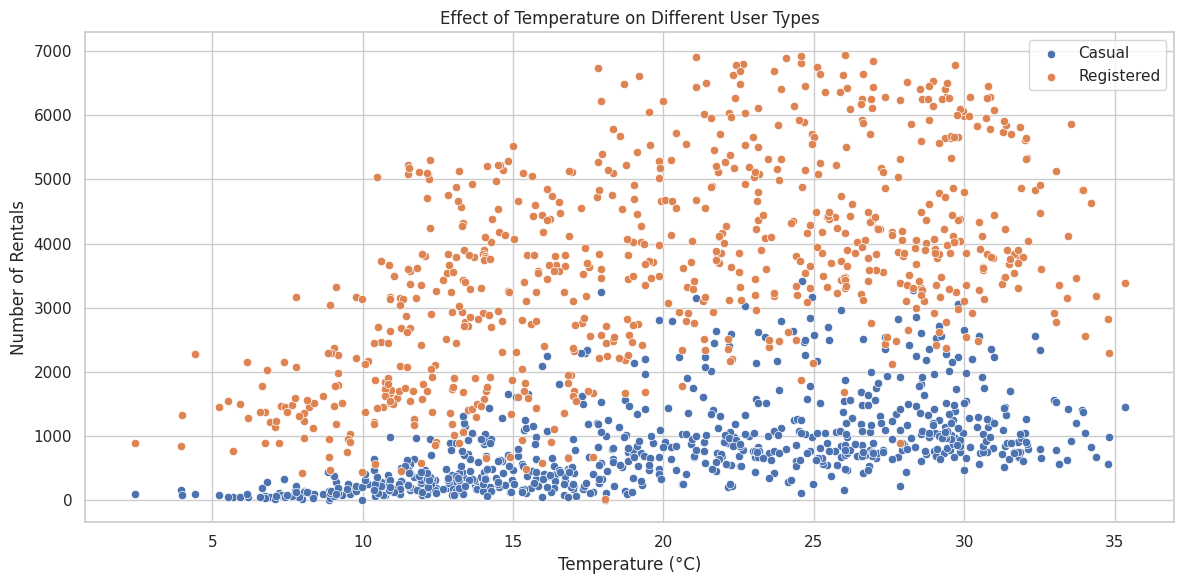

In [18]:
plt.figure(figsize=(12, 6))
sns.scatterplot(x='temp_celsius', y='casual', data=day_clean, label='Casual')
sns.scatterplot(x='temp_celsius', y='registered', data=day_clean, label='Registered')
plt.title('Effect of Temperature on Different User Types')
plt.xlabel('Temperature (°C)')
plt.ylabel('Number of Rentals')
plt.legend()
plt.tight_layout()

**Insight:**
- Semakin tinggi suhu, semakin banyak penyewaan sepeda
  terlihat pola positif di mana jumlah penyewaan meningkat seiring kenaikan suhu.
- Penyewaan lebih sedikit saat suhu rendah (di bawah 10°C) dan meningkat drastis setelah suhu naik di atas 15°C.
- Titik-titik berwarna jingga (registered) jauh lebih banyak dan lebih tinggi dibanding biru (casual).Hal ini menunjukkan bahwa pengguna terdaftar lebih dominan dalam sistem penyewaan sepeda.


### Membuat heatmap correlation untuk variabel numerik dalam dataset day_clean

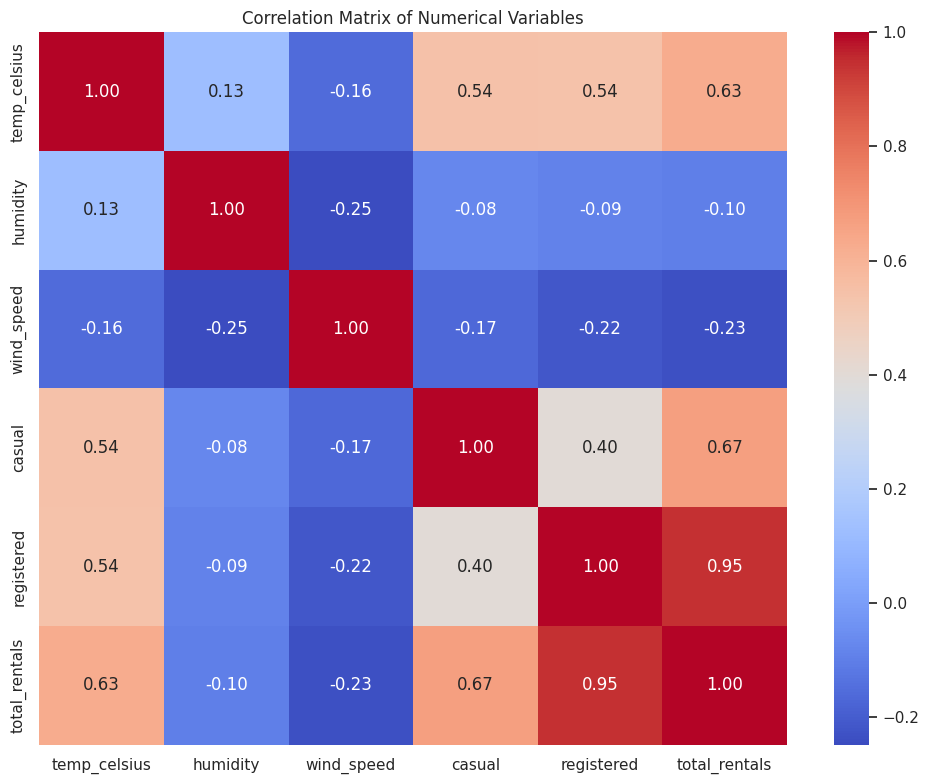

In [19]:
numerical_cols = ['temp_celsius', 'humidity', 'wind_speed', 'casual', 'registered', 'total_rentals']
corr_matrix = day_clean[numerical_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numerical Variables')
plt.tight_layout()

**Insight:**

- Korelasi dengan total rental (0.63) menunjukkan bahwa suhu yang lebih tinggi cenderung meningkatkan penyewaan sepeda. Korelasi yang sama juga terlihat pada casual (0.54) dan registered (0.54).
- Korelasi yang sangat tinggi antara total_rentals dengan registered (0.95). Ini berarti jumlah penyewaan secara keseluruhan sangat dipengaruhi oleh pengguna terdaftar, dibandingkan pengguna casual.


## Visualization & Explanatory Analysis

### Pertanyaan 1: Bagaimana pola penyewaan sepeda berdasarkan waktu (jam, hari, dan musim) dan faktor cuaca?

### Menganalisis dan memvisualisasikan pola penyewaan sepeda berdasarkan jam dalam sehari untuk hari kerja (weekday) dan akhir pekan (weekend)

In [20]:
# Hourly rental patterns
hourly_rentals = hour_clean.groupby('hour')['total_rentals'].sum().reset_index()
weekday_hourly = hour_clean[hour_clean['day_type'] == 'Weekday'].groupby('hour')['total_rentals'].mean().reset_index()
weekend_hourly = hour_clean[hour_clean['day_type'] == 'Weekend'].groupby('hour')['total_rentals'].mean().reset_index()

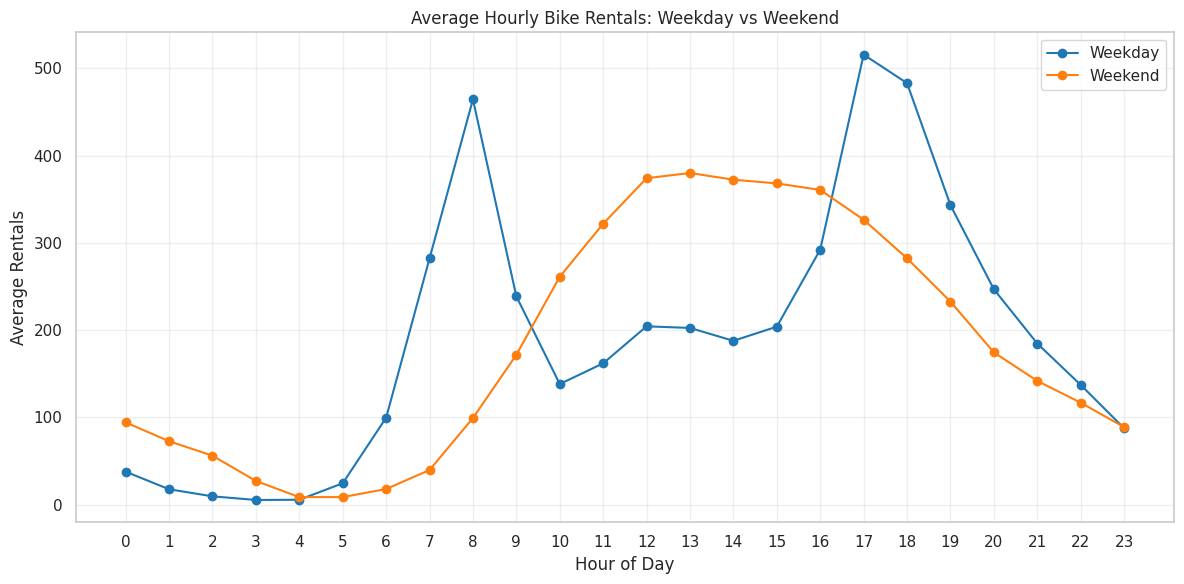

In [21]:
# Plot comparing weekday vs weekend patterns
plt.figure(figsize=(12, 6))
plt.plot(weekday_hourly['hour'], weekday_hourly['total_rentals'], label='Weekday', marker='o', color='#1f77b4')
plt.plot(weekend_hourly['hour'], weekend_hourly['total_rentals'], label='Weekend', marker='o', color='#ff7f0e')
plt.xlabel('Hour of Day')
plt.ylabel('Average Rentals')
plt.title('Average Hourly Bike Rentals: Weekday vs Weekend')
plt.xticks(range(24))
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

**Insight:**
### Pola di Hari Kerja (Weekday)
- Terdapat **dua puncak tajam** di sekitar **jam 8 pagi** dan **jam 5-6 sore**.  
- Ini menunjukkan bahwa pengguna utama di hari kerja adalah **orang yang dengan mobilitas tinggi ambil contoh pekerja** yang menggunakan sepeda untuk pergi dan pulang kerja.  
- Setelah puncak pagi, jumlah penyewaan turun dan stabil hingga sore hari, sebelum naik lagi saat jam pulang kerja.

### Pola di Akhir Pekan (Weekend)
- Penyewaan meningkat lebih stabil sepanjang hari, tanpa lonjakan tajam.
- Puncaknya terjadi sekitar jam **12 siang hingga 4 sore**, yang mencerminkan penggunaan santai.  
- Tidak ada lonjakan pagi atau sore seperti di hari kerja, menunjukkan bahwa penyewaan lebih fleksibel dan tidak terikat jam kerja.

### Menganalisis pola penyewaan sepeda berdasarkan hari dalam seminggu dan menampilkan hasilnya dalam bentuk diagram batang (bar chart)

<ipython-input-22-efb055c46cc0>:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  weekday_rentals = day_clean.groupby("day_of_week")["total_rentals"].sum().reindex(
<ipython-input-22-efb055c46cc0>:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='day_of_week', y='total_rentals', data=weekday_rentals, palette='coolwarm')


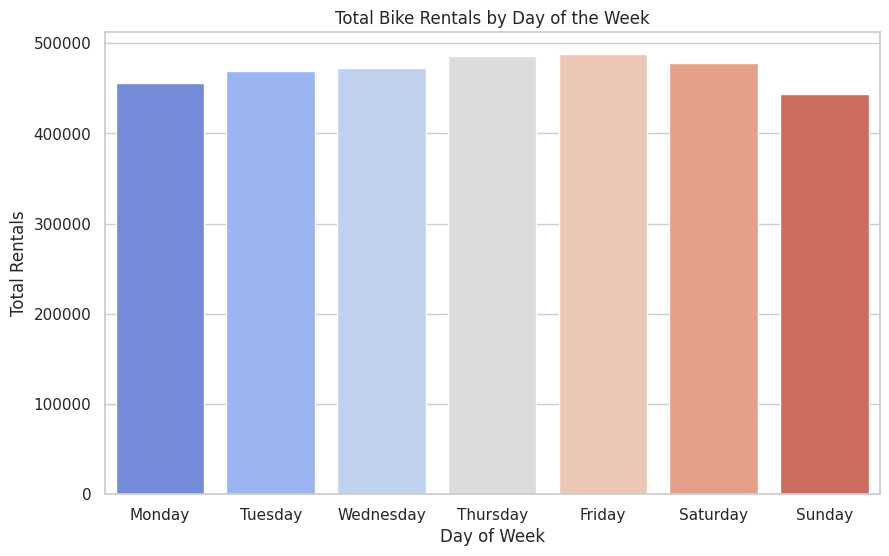

In [22]:
# Weekday rental patterns
weekday_rentals = day_clean.groupby("day_of_week")["total_rentals"].sum().reindex(
    ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
).reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(x='day_of_week', y='total_rentals', data=weekday_rentals, palette='coolwarm')
plt.title('Total Bike Rentals by Day of the Week')
plt.xlabel('Day of Week')
plt.ylabel('Total Rentals')
plt.show()

**Insight:**
- Hari dengan penyewaan tertinggi: **Kamis dan Jumat**
- Hari dengan penyewaan terendah: **Minggu** memiliki jumlah penyewaan paling rendah, kemungkinan karena lebih sedikit yang bekerja.
- **Hari kerja (Senin - Jumat)** memiliki jumlah penyewaan yang relatif tinggi, mencerminkan penggunaan sepeda yang masif.
- **Akhir pekan (Sabtu & Minggu)** cenderung lebih rendah, terutama Minggu, mungkin karena pengguna lebih memilih kegiatan lain.

### Menganalisis total penyewaan sepeda berdasarkan musim (Spring, Summer, Fall, Winter) dan menampilkan hasilnya dalam bentuk diagram batang (bar chart)

<ipython-input-23-485cb69e013e>:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  seasonal_rentals = day_clean.groupby('season')['total_rentals'].sum().reindex(
<ipython-input-23-485cb69e013e>:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='season', y='total_rentals', data=seasonal_rentals, palette='viridis')


Text(0, 0.5, 'Total Rentals')

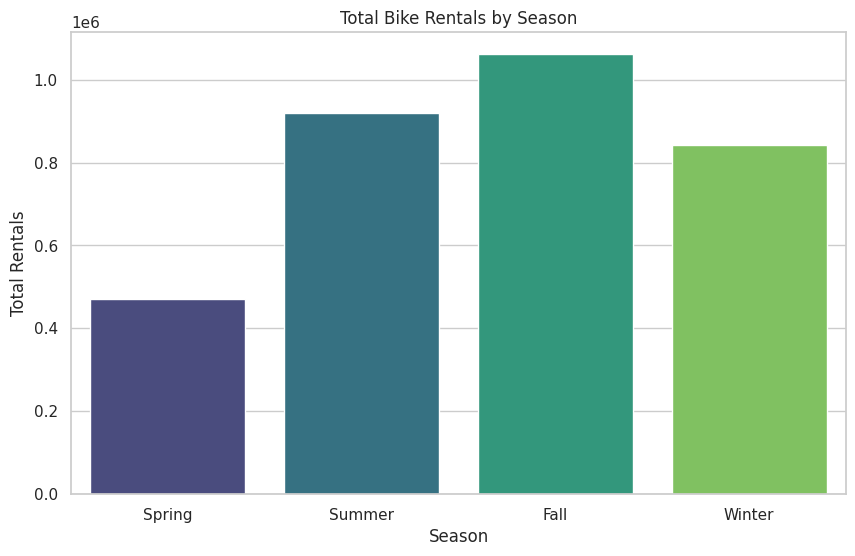

In [23]:
# Seasonal patterns
seasonal_rentals = day_clean.groupby('season')['total_rentals'].sum().reindex(
    ['Spring', 'Summer', 'Fall', 'Winter']
).reset_index()

plt.figure(figsize=(10, 6))
ax = sns.barplot(x='season', y='total_rentals', data=seasonal_rentals, palette='viridis')
plt.title('Total Bike Rentals by Season')
plt.xlabel('Season')
plt.ylabel('Total Rentals')

**Insight:**
- **Penyewaan meningkat dari musim semi ke musim panas**, menunjukkan bahwa semakin hangat cuacanya, semakin banyak orang yang menggunakan sepeda.
- **Musim gugur memiliki penyewaan tertinggi**, kemungkinan karena masih memiliki cuaca yang nyaman dan stabil.
- **Penyewaan menurun di musim dingin**, namun tetap lebih tinggi dibandingkan musim semi.

### Menganalisis hubungan antara kondisi cuaca (weather) dan total penyewaan sepeda (total_rentals) menggunakan boxplot untuk menunjukkan distribusi data

<ipython-input-24-3731f8b6a61d>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='weather', y='total_rentals', data=day_clean, palette="Blues")


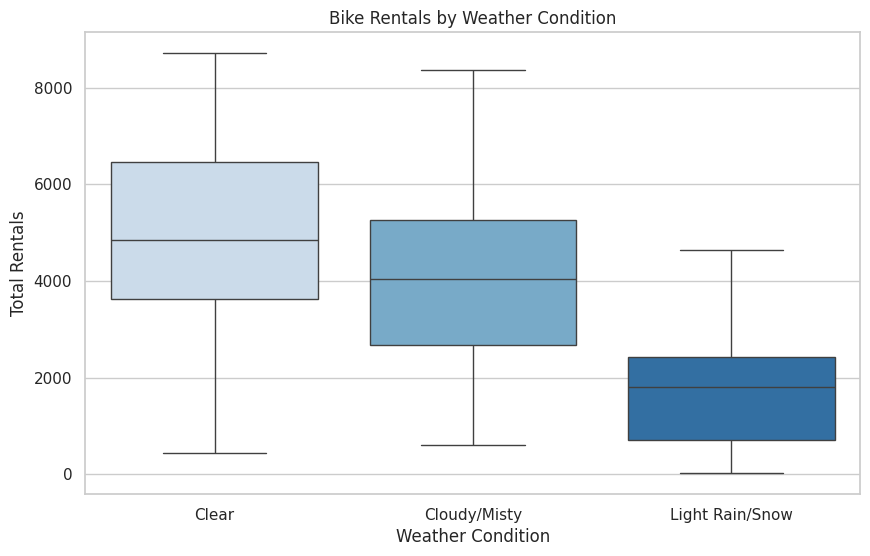

In [24]:
# Weather vs rentals
plt.figure(figsize=(10, 6))
sns.boxplot(x='weather', y='total_rentals', data=day_clean, palette="Blues")
plt.title('Bike Rentals by Weather Condition')
plt.xlabel('Weather Condition')
plt.ylabel('Total Rentals')
plt.show()

**Insight:**
- **Cuaca cerah ("Clear") memiliki jumlah penyewaan tertinggi.**  
  - Rata-rata penyewaan sepeda lebih tinggi dibandingkan kondisi lainnya.
  - Variasi penyewaan cukup besar, dengan beberapa hari memiliki penyewaan yang jauh lebih tinggi.
  
- **Cuaca mendung/berkabut ("Cloudy/Misty") memiliki penyewaan lebih rendah dibandingkan hari cerah.**  
  - Penyewaan masih cukup tinggi, tetapi lebih rendah dibandingkan cuaca cerah.
  - Rentang penyewaan cukup lebar, menunjukkan adanya variabilitas dalam perilaku penyewa.

- **Cuaca hujan ringan/salju ("Light Rain/Snow") memiliki jumlah penyewaan terendah.**  
  - Rata-rata penyewaan jauh lebih sedikit dibandingkan kondisi lainnya.
  - Distribusi lebih sempit, menunjukkan bahwa orang cenderung enggan menyewa sepeda dalam kondisi ini.

### Pertanyaan 2: Apa karakteristik pengguna sepeda dan bagaimana membedakan pelanggan terdaftar (registered) dan kasual (casual)?

### Menganalisis perbedaan jumlah penyewaan sepeda oleh pengguna casual dan registered secara bulanan, serta menampilkannya dalam bentuk diagram batang (bar chart)

In [25]:
# Compare casual vs. registered users over time
user_type_monthly = day_clean.groupby(['month_year']).agg({
    'casual': 'sum',
    'registered': 'sum',
    'total_rentals': 'sum'
}).reset_index()

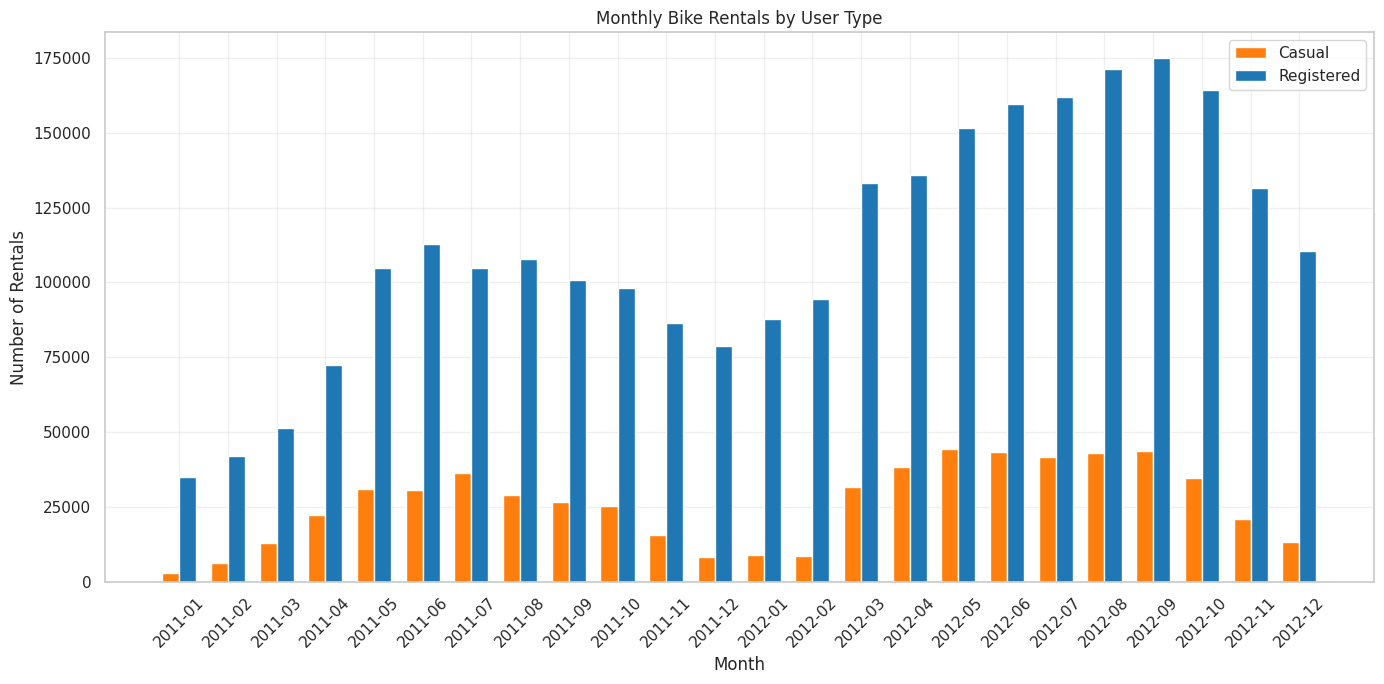

In [26]:
# Convert Period to string for better plotting
user_type_monthly['month_year_str'] = user_type_monthly['month_year'].astype(str)

plt.figure(figsize=(14, 7))
width = 0.35
x = np.arange(len(user_type_monthly))

plt.bar(x - width/2, user_type_monthly['casual'], width, label='Casual', color='#ff7f0e')
plt.bar(x + width/2, user_type_monthly['registered'], width, label='Registered', color='#1f77b4')

plt.xlabel('Month')
plt.ylabel('Number of Rentals')
plt.title('Monthly Bike Rentals by User Type')
plt.xticks(x, user_type_monthly['month_year_str'], rotation=45)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

**Insight:**
- **Pengguna Terdaftar (Registered) mendominasi penyewaan sepeda** setiap bulan. Lonjakan jumlah sejalan dengan musim, meningkat tajam pada musim panas.
- **Pengguna Casual (Tidak Terdaftar) cenderung lebih sedikit** dibanding pengguna terdaftar. Penyewaan oleh pengguna casual meningkat di musim panas, tetapi penurunannya lebih drastis di musim dingin.
- **Musim panas (Juni-September)** memiliki jumlah penyewaan tertinggi, baik untuk pengguna casual maupun terdaftar.
- **Musim dingin (Desember-Februari)** memiliki jumlah penyewaan yang jauh lebih rendah, terutama untuk pengguna casual.

## Analisis Lanjutan (Opsional)

Setelah eksplorasi awal, saya melakukan analisis lanjutan. Metode yang digunakan adalah:  

### **Clustering (Manual Grouping)**  
Clustering ini bertujuan untuk mengelompokkan pola penyewaan sepeda berdasarkan jam.

#### **Kategori Waktu**

| **Kategori**  | **Jam**                      | **Penjelasan**                                     |
|--------------|----------------------------|-------------------------------------------------|
| **Peak Hours**  | 07:00 - 09:00, 17:00 - 19:00 | Puncak penyewaan saat berangkat & pulang kerja. |
| **Midday**     | 09:00 - 17:00               | Waktu penyewaan normal di siang & sore hari.   |
| **Off-Peak**  | 00:00 - 06:00, 22:00 - 23:59 | Penyewaan rendah di malam hari & dini hari.    |



In [27]:
def create_hourly_pivot(df: pd.DataFrame) -> pd.DataFrame:
    """
    Creates a pivot table to calculate the average bike rentals per hour.

    Parameters:
        df (pd.DataFrame): The hourly dataset.

    Returns:
        pd.DataFrame: Pivot table with average rentals per hour for weekdays and weekends.
    """
    return df.pivot_table(
        index='hour',
        columns='day_type',
        values='total_rentals',
        aggfunc='mean'
    ).reset_index()

def classify_time_period(hour: int) -> str:
    """
    Classifies an hour into predefined time periods based on rental patterns.

    Parameters:
        hour (int): The hour of the day (0-23).

    Returns:
        str: The time period category ('Peak Hours', 'Midday', 'Off-Peak').
    """
    if 7 <= hour <= 9 or 17 <= hour <= 19:
        return 'Peak Hours'
    if 0 <= hour <= 6 or 22 <= hour <= 23:
        return 'Off-Peak'
    return 'Midday'

# Clustering
def assign_clusters(df: pd.DataFrame) -> pd.DataFrame:
    """
    Assigns time period clusters to each hour based on predefined rules.

    Parameters:
        df (pd.DataFrame): DataFrame containing hourly rental data.

    Returns:
        pd.DataFrame: Updated DataFrame with an additional 'cluster' column.
    """
    df['cluster'] = df['hour'].apply(classify_time_period)
    return df

hourly_patterns = create_hourly_pivot(hour_clean)
hourly_patterns = assign_clusters(hourly_patterns)

hourly_patterns[['hour', 'cluster']].head(24)

day_type,hour,cluster
0,0,Off-Peak
1,1,Off-Peak
2,2,Off-Peak
3,3,Off-Peak
4,4,Off-Peak
5,5,Off-Peak
6,6,Off-Peak
7,7,Peak Hours
8,8,Peak Hours
9,9,Peak Hours


**Insight:**
### **1️⃣ Peak Hours (07:00-09:00 & 17:00-19:00)**  
- Jam sibuk pagi dan sore mencerminkan **pengguna yang berangkat dan pulang kerja.**

### **2️⃣ Midday (10:00-16:00 & 20:00-21:00)**
- **Pengguna kasual (Casual) lebih aktif pada siang hari dan sore menjelang malam.**  

### **3️⃣ Off-Peak (00:00-06:00 & 22:00-23:00)**
- Penyewaan sepeda sangat sedikit karena mayoritas orang tidak beraktivitas pada waktu ini.

## Conclusion

- Conclution pertanyaan 1 : Pola penyewaan sepeda sangat dipengaruhi oleh waktu, musim, dan cuaca. Penggunaan sepeda mencapai puncaknya pada jam sibuk (pagi dan sore hari) serta musim gugur. Cuaca juga memainkan peran penting, dengan hari cerah meningkatkan penyewaan, sedangkan hujan dan salju menguranginya secara signifikan.
- Conclution pertanyaan 2 : Pengguna terdaftar (registered) mendominasi penyewaan sepeda, terutama pada hari kerja, dan memiliki pola penggunaan yang lebih stabil sepanjang tahun. Pengguna kasual (casual) lebih aktif pada akhir pekan dan bulan-bulan musim panas, serta lebih dipengaruhi oleh faktor cuaca dan musim.

In [28]:
!pipreqsnb . --force

pipreqs  --force .
INFO: Not scanning for jupyter notebooks.
INFO: Successfully saved requirements file in ./requirements.txt
